# ECE 143 Final Project Setup


## Data sources

Raw data lives in **`data/raw/`**; processed output in **`data/processed/`**.

- Olist Brazilian E-Commerce: [Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/data)
- E-Commerce Customer Insights and Churn: [Kaggle](https://www.kaggle.com/datasets/nabihazahid/e-commerce-customer-insights-and-churn-dataset/data)


## Data PreProcessing

In [4]:
# Imports
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Data loading (placeholder)
# df = pd.read_csv('path/to/data.csv')
# df.head()

def get_olist_behavioral_features(orders_path, customers_path, payments_path, reviews_path):
    '''
    Extracts core RFM metrics and customer satisfaction scores.
    
    Parameters:
        orders_path (str): Path to olist_orders_dataset.csv
        customers_path (str): Path to olist_customers_dataset.csv
        payments_path (str): Path to olist_order_payments_dataset.csv
        reviews_path (str): Path to olist_order_reviews_dataset.csv
        
    Returns:
        pd.DataFrame: Aggregated behavioral data per unique customer.
    '''
    for path in [orders_path, customers_path, payments_path, reviews_path]:
        assert isinstance(path, str), f"Path {path} must be a string"

    # Load and merge
    orders = pd.read_csv(orders_path)
    cust = pd.read_csv(customers_path)
    pay = pd.read_csv(payments_path).groupby('order_id')['payment_value'].sum()
    rev = pd.read_csv(reviews_path).groupby('order_id')['review_score'].mean()

    df = orders.merge(cust, on='customer_id').merge(pay, on='order_id', how='left')
    df = df.merge(rev, on='order_id', how='left')

    # Time and Behavioral
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    snapshot = df['order_purchase_timestamp'].max()

    features = df.groupby('customer_unique_id').agg({
        'order_purchase_timestamp': [lambda x: (snapshot - x.max()).days, # Recency
                                     lambda x: (snapshot - x.min()).days], # Tenure
        'order_id': 'count',      # Frequency
        'payment_value': 'sum',   # Monetary
        'review_score': 'mean'    # Sentiment (Satisfaction)
    }).reset_index()

    features.columns = ['customer_id', 'recency', 'tenure_days', 'frequency', 'monetary', 'avg_review']
    return features

def process_labeled_ecommerce_features(churn_path, churn_if_cancelled_only = False):
    '''
    Processes the labeled churn dataset with temporal and financial engineering.
    
    Parameters:
        churn_path (str): Path to ECommerceAndChurnDataset.csv
        
    Returns:
        pd.DataFrame: Validated features aligned with the Olist schema.
    '''
    assert isinstance(churn_path, str), "Churn path must be a string"
    
    df = pd.read_csv(churn_path)
    
    # Validation
    required_cols = ["signup_date", "last_purchase_date", "order_date", "subscription_status"]
    for col in required_cols:
        assert col in df.columns, f"Required column {col} missing from Churn dataset"

    # Date Parsing 
    for col in ["signup_date", "last_purchase_date", "order_date"]:
        df[col] = pd.to_datetime(df[col], format="mixed", dayfirst=False)

    # Engineering features to match Olist schema
    ref_date = df["order_date"].max()
    df["tenure_days"] = (ref_date - df["signup_date"]).dt.days
    df["recency"] = (ref_date - df["last_purchase_date"]).dt.days
    df["monetary"] = df["unit_price"] * df["quantity"]
    
    # Target creation
    if churn_if_cancelled_only:
        df["churn"] = (df["subscription_status"] == "cancelled").astype(int)
    else:
        df["churn"] = df["subscription_status"].isin(["cancelled", "paused"]).astype(int)
    
    # Selection and Rename
    feats = df[['customer_id', 'recency', 'tenure_days', 'purchase_frequency', 'monetary', 'churn']].copy()
    feats.rename(columns={'purchase_frequency': 'frequency'}, inplace=True)
    
    return feats

def preprocess_dataset(dataset_dir):
    '''
    Combines Olist and Labeled data into a single validated intelligence file.
    
    Parameters:
        dataset_dir (str): Root directory containing the raw CSV files.
        
    Returns:
        pd.DataFrame: Final unified dataset ready for modeling.
    '''
    # Process Olist (Behavioral Branch)
    behavior = get_olist_behavioral_features(
        f'{dataset_dir}/olist_orders_dataset.csv', 
        f'{dataset_dir}/olist_customers_dataset.csv', 
        f'{dataset_dir}/olist_order_payments_dataset.csv', 
        f'{dataset_dir}/olist_order_reviews_dataset.csv'
    )
    
    # Apply Churn Logic to Olist (Inactivity OR Sentiment)
    behavior['churn'] = ((behavior['recency'] > 90) | (behavior['avg_review'] < 2)).astype(int)
    behavior['source'] = 'Olist'

    # Process Labeled Dataset (Subscription Branch)
    labeled = process_labeled_ecommerce_features(f'{dataset_dir}/ECommerceAndChurnDataset.csv')
    labeled['source'] = 'Labeled'

    # Concatenate and Impute
    # final_feats = pd.concat([behavior, labeled], ignore_index=True)
    
    # Fill missing reviews in labeled set with the global average
    # final_feats['avg_review'] = final_feats['avg_review'].fillna(final_feats['avg_review'].mean())
    behavior['avg_review'] = behavior['avg_review'].fillna(behavior['avg_review'].mean())
    
    return behavior, labeled

In [6]:
DATA_DIR = "../data/raw"
behavior, labeled = preprocess_dataset(str(DATA_DIR))

In [7]:
behavior

,customer_id,recency,tenure_days,frequency,monetary,avg_review,churn,source
0,0000366f3b9a7992bf8c76cfdf3221e2,160,160,1,141.90,5.0,1,Olist
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,163,1,27.19,4.0,1,Olist
2,0000f46a3911fa3c0805444483337064,585,585,1,86.22,3.0,1,Olist
3,0000f6ccb0745a6a4b88665a16c9f078,369,369,1,43.62,4.0,1,Olist
4,0004aac84e0df4da2b147fca70cf8255,336,336,1,196.89,5.0,1,Olist
...,...,...,...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,495,495,1,2067.42,5.0,1,Olist
96092,fffea47cd6d3cc0a88bd621562a9d061,310,310,1,84.58,4.0,1,Olist
96093,ffff371b4d645b6ecea244b27531430a,617,617,1,112.46,5.0,1,Olist
96094,ffff5962728ec6157033ef9805bacc48,168,168,1,133.69,5.0,1,Olist


In [8]:
labeled

,customer_id,recency,tenure_days,frequency,monetary,churn,source
0,CUST1000,911,1686,37,391.05,0,Labeled
1,CUST1001,1351,1766,35,512.16,0,Labeled
2,CUST1002,716,802,44,1208.28,1,Labeled
3,CUST1003,547,752,1,338.64,1,Labeled
4,CUST1004,340,1715,35,438.62,0,Labeled
...,...,...,...,...,...,...,...
1995,CUST2995,760,1501,25,212.38,0,Labeled
1996,CUST2996,661,998,12,1144.14,1,Labeled
1997,CUST2997,1101,1218,38,1830.30,0,Labeled
1998,CUST2998,248,1557,49,229.14,0,Labeled


In [10]:
_processed_dir = Path("../data/processed")
behavior.to_csv(_processed_dir / "olist_churn_features.csv", index=False)
labeled.to_csv(_processed_dir / "labeled_churn_features.csv", index=False)
print(f"Saved processed data to {_processed_dir}")


Saved processed data to ../data/processed


In [15]:
def plot_feature_importance(df):
    '''
    Trains a diagnostic Random Forest to rank features by their predictive 
    power regarding customer churn.
    '''
    # Select numeric features for modeling
    # Eengineered RFM + Sentiment + Tenure metrics
    behavior_features = ['recency', 'tenure_days', 'frequency', 'monetary', 'avg_review']
    labeled_features = ['recency', 'tenure_days', 'frequency', 'monetary']
    
    # Ensure we only use rows that have these features 
    if df.columns.isin(behavior_features).all():
        features = behavior_features
        model_df = df.dropna(subset=features + ['churn'])
    else:
        features = labeled_features
        model_df = df.dropna(subset=features + ['churn'])
    
    X = model_df[features]
    y = model_df['churn']
    
    # Random Forest is robust to the 'long tail' distributions in e-commerce
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    # Create a DataFrame for visualization
    importances = pd.DataFrame({
        'Feature': features,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
    
    plt.title('Feature Importance: Key Drivers of Customer Churn', fontsize=14, pad=20)
    plt.xlabel('Importance Score (Predictive Contribution)', fontsize=12)
    plt.ylabel('Customer Metric', fontsize=12)
    
    # Add data labels 
    for i in ax.containers:
        ax.bar_label(i, fmt='%.3f', padding=5)

    plt.tight_layout()
    plt.show()

/var/folders/h0/1t_8wxys0c38mc2r9613xgjm0000gn/T/ipykernel_34300/4147295261.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


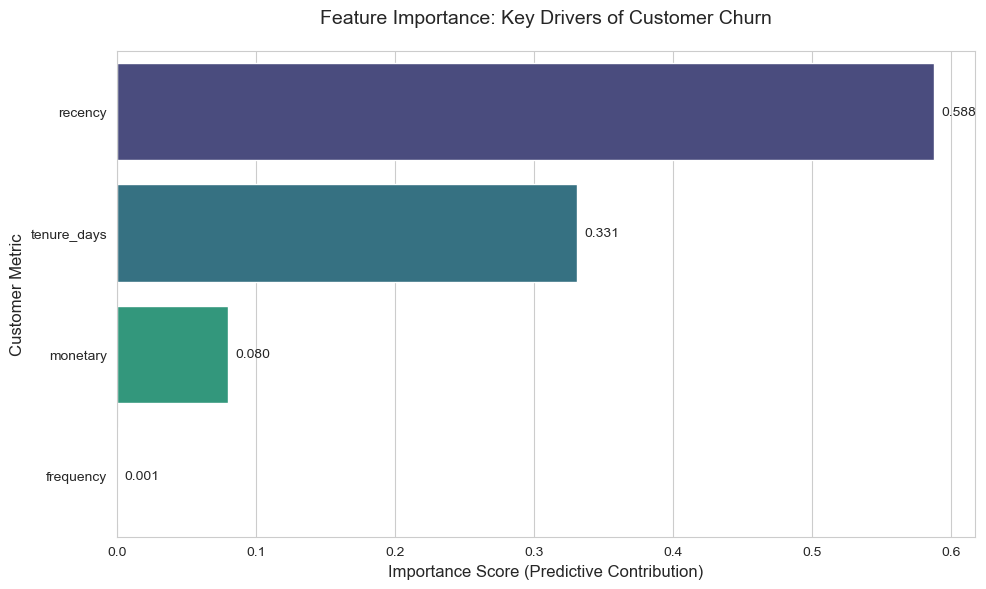

/var/folders/h0/1t_8wxys0c38mc2r9613xgjm0000gn/T/ipykernel_34300/4147295261.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


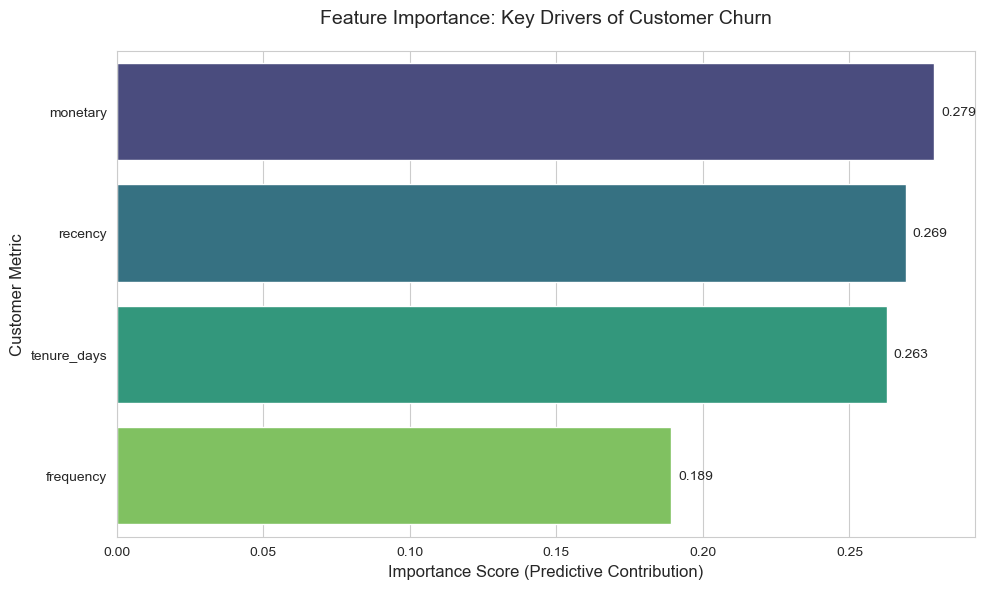

In [16]:
plot_feature_importance(behavior)
plot_feature_importance(labeled)